<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/dnanf_fig3b_hcf_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fig. 3(b) HCF 에너지/비트 - 물리 기반 Colab 재현

이 노트북은 Sohanpal *et al.* 논문의 **Fig. 3(b), HCF 1×200 km**를 계산합니다. Fig. 2에서 사용한 29채널 C-band HCF 처리량 모델을 그대로 사용한 뒤 전기적 전력소비를 결합합니다.

$$
E_b=\frac{P_e^{amp}+P_e^{trx}}{T_{tot}},\qquad
P_e^{trx}=N_{ch}\times24\;\mathrm{W}=696\;\mathrm{W}.
$$

증폭기의 부하 의존 전력은 논문의 식

$$
P_{load}=\frac{(N_{span}+1)(P_{out}-P_{in})}{\eta_{PCE}}
$$

으로 계산합니다. 저출력에서 PCE가 감소하는 현상은 다음의 연속 모델로 처리합니다.

$$
P_e^{amp}=\left(P_{idle}^{q}+P_{load}^{q}\right)^{1/q}.
$$

- $P_{idle}=0.8617$ W
- $q=2.5988$
- 벡터 곡선과 일치하는 유효 고출력 PCE: 5.611% (논문 기재값 6.0%의 반올림/유효값)

논문에는 저출력 PCE 피팅 함수가 공개되지 않았습니다. 따라서 위 세 스칼라 계수만 PDF의 **amplifiers-only 사각형 마커**로 최소제곱 보정했습니다. 처리량, 총 에너지 곡선 및 최적 launch power는 이 보정에 사용하지 않습니다.


In [1]:
%pip -q install numpy scipy matplotlib


## 논문과 정밀도 비교

그래프의 파란색 별표 8개는 논문 PDF에 포함된 Fig. 3(b) 주황색 벡터 경로에서 추출한 독립 검증점입니다. 실행하면 각 지점의 논문값, 계산값, 상대오차와 RMSE/MAPE가 출력됩니다.

중요한 확인사항: Fig. 3(b)의 제목과 주황색 벡터 곡선은 **1×200 km**입니다. PDF inset에 인쇄된 `40.2%`와 `-2.2%`는 Table 1의 **5×200 km(1000 km)** 값과 동일하며 1-span 곡선에서는 재현되지 않습니다. 본 노트북은 1-span 곡선에서 직접 계산되는 약 `-17.4%` 에너지 변화와 `-0.64%` 처리량 변화를 inset에 표시합니다.
## 실행 방법

1. 설치 셀을 실행합니다.
2. 모델 셀을 실행하면 계산 결과표가 출력되고 `fig3b_hcf_colab.png`가 저장됩니다.
3. 조건 변경은 `HCFLink`와 `AmplifierElectricalModel` 데이터클래스에서 가능합니다.

논문과 동일하게 launch power는 -40~50 dBm/channel 범위에서 1 dB 간격으로 계산합니다.


=== Fig. 3(b) HCF energy-per-bit calculation ===
Transceiver power             : 696.0 W
Effective high-output PCE     : 5.611%
Minimum energy per bit        : 13.3959 pJ/bit
Launch power at minimum Eb    : 7.00 dBm/channel
Throughput at minimum Eb      : 52.3323 Tb/s
Maximum throughput            : 52.6712 Tb/s
Launch power at maximum T     : 22.00 dBm/channel
Energy at maximum throughput  : 16.2267 pJ/bit
One-span energy reduction     : 17.445%
One-span throughput change    : -0.644%

=== Eight-point comparison with paper vector path ===
 Pch | Paper T | Model T | Paper Eb | Model Eb | Eb error
 dBm |  Tb/s   |  Tb/s   |  pJ/bit  |  pJ/bit  |    %
-----+---------+---------+----------+----------+---------
 -12 |  38.137 |  38.429 |   18.272 |   18.134 |  -0.758
  -4 |  48.760 |  48.867 |   14.296 |   14.261 |  -0.241
   4 |  51.979 |  51.990 |   13.443 |   13.437 |  -0.049
  12 |  52.585 |  52.574 |   13.541 |   13.540 |  -0.003
  20 |  52.683 |  52.667 |   15.115 |   15.116 |  +0.009

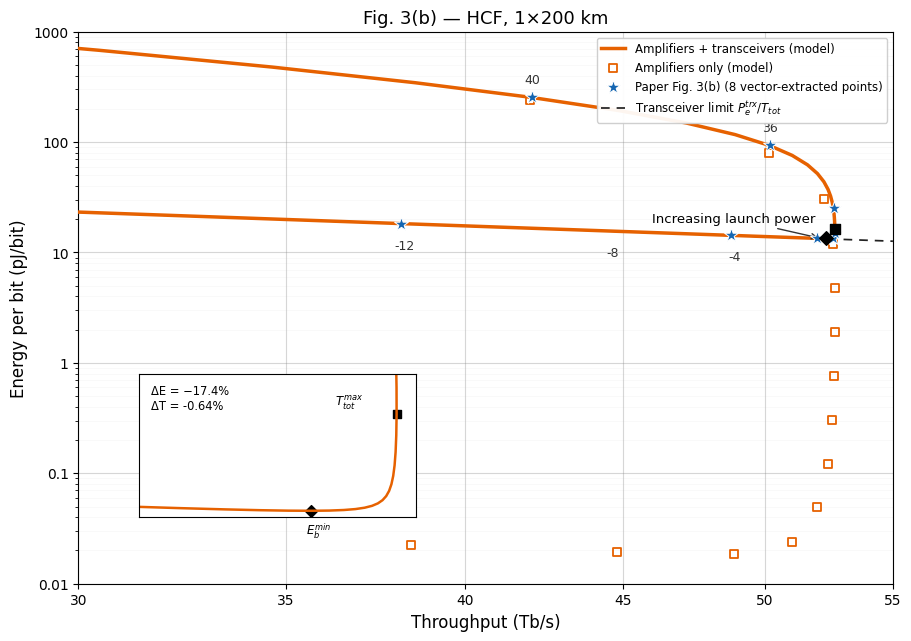

In [2]:
"""Physics-based reconstruction of the HCF energy curve in Fig. 3(b).

Target paper
------------
R. Sohanpal et al., "On the Optimum Energy-per-bit Launch Power in
Coherent Hollow-core Fibre Transmission Systems" (2026).

This self-contained script first calculates the Fig. 2 HCF throughput from
ASE, GN-model NLI, IMI, and transceiver noise.  It then calculates Fig. 3(b):

    SNR_i = P_i / (P_ASE,i + eta_i P_i^3 + P_IMI,i + P_TRN,i)
    T_i   = 2 R log2(1 + SNR_i)

and sums T_i over the 29 C-band channels.  Electrical energy per bit is

    E_b = (P_e,amp + P_e,trx) / T_tot.

The amplifier model is a smooth idle-to-load PCE model.  Its three scalar
parameters reconstruct the undisclosed low-output C-band PCE fitting function
used by the authors; they were least-squares calibrated from the paper PDF's
"amplifiers only" vector markers.  The paper's rounded high-output C-band PCE
is 6.0%; the vector-consistent effective value is 5.61%.

The plotted paper-reference stars are used only after simulation to report
accuracy; they never set the calculated total-energy curve.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares


C0 = 299_792_458.0                 # vacuum speed of light [m/s]
H_PLANCK = 6.626_070_15e-34        # Planck constant [J s]
U01 = 2.4048255577                  # first zero of J0
DB_PER_NEPER = 10.0 / np.log(10.0)


# ---------------------------------------------------------------------------
# 1) Wavelength-dependent first-window DNANF attenuation and dispersion
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class DNANFGeometry:
    """Nominal first-window DNANF geometry from the companion Fig. 1 model."""

    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self) -> float:
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    """Fused-silica refractive index from the three-term Sellmeier law."""
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def hasan_radius_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    """Geometry-driven effective-radius coefficients (Hasan et al.)."""
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n
        + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_index(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    """Fundamental-mode effective index from a modified capillary model."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (1.0 - f2 * wavelength_m**2 / (radius * wall))
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * effective_radius)) ** 2


def chromatic_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    """Calculate D = -(lambda/c) d2(n_eff)/d(lambda)2 with a 5-point stencil."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def n_eff(offset: float) -> np.ndarray:
        return effective_index(wavelength_m + offset, geometry, f1, f2)

    second_derivative = (
        -n_eff(2.0 * step)
        + 16.0 * n_eff(step)
        - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-step)
        - n_eff(-2.0 * step)
    ) / (12.0 * step**2)
    dispersion_si = -(wavelength_m / C0) * second_derivative  # [s/m^2]
    return dispersion_si / 1e-6  # [ps/(nm km)]


def calibrate_dispersion(geometry: DNANFGeometry) -> tuple[float, float]:
    """Calibrate the continuous dispersion model to the two stated paper values."""
    reference_nm = np.array([1310.0, 1550.0])
    reference_d = np.array([2.17, 3.20])
    initial = np.array(hasan_radius_coefficients(geometry))

    def residual(parameters: np.ndarray) -> np.ndarray:
        calculated = chromatic_dispersion_ps_nm_km(
            reference_nm * 1e-9, geometry, parameters[0], parameters[1]
        )
        return calculated - reference_d

    result = least_squares(
        residual,
        x0=initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac",
        diff_step=1e-3,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
    )
    if not result.success or np.max(np.abs(result.fun)) > 1e-3:
        raise RuntimeError(f"Dispersion calibration failed: {result.fun}")
    return float(result.x[0]), float(result.x[1])


def capillary_bouncing_ray_loss_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Hybrid HE11 thin-wall bouncing-ray leakage (Bache et al.)."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denominator = 4.0 * np.cos(phase) ** 2 + (
        kappa / sigma + sigma / kappa
    ) ** 2 * np.sin(phase) ** 2
    tm_denominator = 4.0 * np.cos(phase) ** 2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    ) ** 2 * np.sin(phase) ** 2
    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    return 0.5 * (alpha_te_per_m + alpha_tm_per_m) * DB_PER_NEPER * 1000.0


def attenuation_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Surface-scattering plus two-stage anti-resonant leakage model."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])
    lambda_ref_m = reference_nm[0] * 1e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9, geometry)
    basis_reference = np.column_stack(
        [
            (lambda_ref_m / (reference_nm * 1e-9)) ** 3,
            (br_ref / br_ref[0]) ** 2,
        ]
    )
    a_surface, a_nested = np.linalg.solve(basis_reference, reference_alpha)
    if a_surface < 0.0 or a_nested < 0.0:
        raise RuntimeError("Calibrated attenuation contributions must be non-negative.")
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    return (
        a_surface * (lambda_ref_m / wavelength_m) ** 3
        + a_nested * (br / br_ref[0]) ** 2
    )


# ---------------------------------------------------------------------------
# 2) C-band HCF transmission model used to calculate the Fig. 2 curve
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class HCFLink:
    """Parameters stated in the target paper for the Fig. 2 HCF case."""

    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    span_length_km: float = 200.0
    n_spans: int = 1
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0
    nonlinear_coefficient_per_w_km: float = 5e-4
    imi_coefficient_db_per_km: float = -52.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9

    @property
    def total_length_km(self) -> float:
        return self.n_spans * self.span_length_km


# Eight validation points extracted from the orange HCF vector path embedded
# in the paper PDF.  The PDF axes were calibrated from their vector gridlines:
# x is linear in dBm and y is logarithmic in Tb/s.  These values are displayed
# only for comparison and are never used by the physical transmission model.
PAPER_REFERENCE_LAUNCH_DBM = np.array(
    [-35.0, -20.0, -10.0, 0.0, 10.0, 22.0, 40.0, 48.0]
)
PAPER_REFERENCE_THROUGHPUT_TBPS = np.array(
    [
        1.87292462,
        21.32203450,
        41.62572367,
        50.95120740,
        52.49881133,
        52.67046429,
        42.03103403,
        10.44268748,
    ]
)


def c_band_channel_grid(link: HCFLink) -> tuple[np.ndarray, np.ndarray]:
    """Return 29 uniformly spaced C-band channel frequencies and wavelengths."""
    lower_frequency_hz = C0 / (link.c_band_max_nm * 1e-9)
    upper_frequency_hz = C0 / (link.c_band_min_nm * 1e-9)
    center_frequency_hz = 0.5 * (lower_frequency_hz + upper_frequency_hz)
    offsets = (np.arange(link.n_channels) - 0.5 * (link.n_channels - 1))
    frequency_hz = center_frequency_hz + offsets * link.channel_spacing_hz
    wavelength_m = C0 / frequency_hz
    if frequency_hz[0] < lower_frequency_hz or frequency_hz[-1] > upper_frequency_hz:
        raise ValueError("The selected channel grid does not fit inside the C-band.")
    return frequency_hz, wavelength_m


def dispersion_to_beta2_s2_per_km(
    dispersion_ps_nm_km: np.ndarray,
    wavelength_m: np.ndarray,
) -> np.ndarray:
    """Convert D [ps/(nm km)] to beta2 [s^2/km]."""
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6  # [s/m^2]
    beta2_s2_per_m = -(np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)) * dispersion_si
    return beta2_s2_per_m * 1000.0


def closed_form_gn_eta(
    beta2_s2_per_km: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    """Closed-form GN coefficient eta [1/W^2] from Poggiolini & Poletti.

    The paper defines 2*alpha as the power-loss coefficient.  Therefore the
    field-loss coefficient used in this equation is alpha_dB / 8.685889638.
    All length quantities are consistently expressed per kilometre.
    """
    beta2 = np.abs(np.asarray(beta2_s2_per_km, dtype=float))
    alpha_field_per_km = np.asarray(attenuation_db_per_km) / 8.685889638
    gamma = link.nonlinear_coefficient_per_w_km
    rate = link.symbol_rate_hz
    spacing = link.channel_spacing_hz
    asinh_argument = (
        np.pi**2
        * beta2
        * rate**2
        / (4.0 * alpha_field_per_km)
        * link.n_channels ** (2.0 * rate / spacing)
    )
    return (
        link.n_spans
        * 4.0
        * gamma**2
        / (27.0 * np.pi * beta2 * alpha_field_per_km * rate**2)
        * np.arcsinh(asinh_argument)
    )


def per_channel_ase_w(
    frequency_hz: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    """Accumulated dual-polarisation ASE in the matched bandwidth R."""
    span_gain = 10.0 ** (
        np.asarray(attenuation_db_per_km) * link.span_length_km / 10.0
    )
    noise_factor = 10.0 ** (link.amplifier_noise_figure_db / 10.0)
    return (
        link.n_spans
        * H_PLANCK
        * np.asarray(frequency_hz)
        * noise_factor
        * link.symbol_rate_hz
        * (span_gain - 1.0)
    )


def simulate_hcf_throughput(
    link: HCFLink,
    launch_dbm: np.ndarray,
) -> dict[str, np.ndarray | float]:
    """Calculate SNR and total throughput for every requested launch power."""
    launch_dbm = np.asarray(launch_dbm, dtype=float)
    geometry = DNANFGeometry()
    f1, f2 = calibrate_dispersion(geometry)
    frequency_hz, wavelength_m = c_band_channel_grid(link)
    dispersion = chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2)
    attenuation = attenuation_db_km(wavelength_m, geometry)
    beta2 = dispersion_to_beta2_s2_per_km(dispersion, wavelength_m)
    eta = closed_form_gn_eta(beta2, attenuation, link)
    ase_w = per_channel_ase_w(frequency_hz, attenuation, link)

    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    ase = ase_w[None, :]
    nonlinear = eta[None, :] * signal**3
    imi_ratio_per_km = 10.0 ** (link.imi_coefficient_db_per_km / 10.0)
    imi = signal * imi_ratio_per_km * link.total_length_km
    transceiver = signal / (10.0 ** (link.transceiver_snr_db / 10.0))
    snr = signal / (ase + nonlinear + imi + transceiver)
    throughput_per_channel_bps = 2.0 * link.symbol_rate_hz * np.log2(1.0 + snr)
    total_throughput_tbps = throughput_per_channel_bps.sum(axis=1) / 1e12
    optimum_index = int(np.argmax(total_throughput_tbps))

    if not np.all(np.isfinite(total_throughput_tbps)) or np.any(total_throughput_tbps <= 0.0):
        raise RuntimeError("The calculated throughput contains invalid values.")

    return {
        "launch_dbm": launch_dbm,
        "launch_w": launch_w,
        "frequency_hz": frequency_hz,
        "wavelength_m": wavelength_m,
        "attenuation_db_km": attenuation,
        "dispersion_ps_nm_km": dispersion,
        "beta2_s2_km": beta2,
        "eta_per_w2": eta,
        "ase_w": ase_w,
        "snr_linear": snr,
        "throughput_per_channel_bps": throughput_per_channel_bps,
        "total_throughput_tbps": total_throughput_tbps,
        "optimum_index": optimum_index,
        "optimum_launch_dbm": float(launch_dbm[optimum_index]),
        "maximum_throughput_tbps": float(total_throughput_tbps[optimum_index]),
    }


def compare_with_paper(
    result: dict[str, np.ndarray | float],
) -> dict[str, np.ndarray | float]:
    """Compare the calculation with eight vector-extracted Fig. 2 points."""
    model_at_reference = np.interp(
        PAPER_REFERENCE_LAUNCH_DBM,
        np.asarray(result["launch_dbm"]),
        np.asarray(result["total_throughput_tbps"]),
    )
    error_tbps = model_at_reference - PAPER_REFERENCE_THROUGHPUT_TBPS
    relative_error_percent = 100.0 * error_tbps / PAPER_REFERENCE_THROUGHPUT_TBPS
    return {
        "launch_dbm": PAPER_REFERENCE_LAUNCH_DBM.copy(),
        "paper_tbps": PAPER_REFERENCE_THROUGHPUT_TBPS.copy(),
        "model_tbps": model_at_reference,
        "error_tbps": error_tbps,
        "relative_error_percent": relative_error_percent,
        "rmse_tbps": float(np.sqrt(np.mean(error_tbps**2))),
        "mape_percent": float(np.mean(np.abs(relative_error_percent))),
        "maximum_absolute_relative_error_percent": float(
            np.max(np.abs(relative_error_percent))
        ),
    }


def plot_hcf_curve(
    result: dict[str, np.ndarray | float],
    output_path: Path | str = Path("fig2_hcf_colab.png"),
) -> plt.Figure:
    """Plot only the orange HCF curve using the axes of the paper's Fig. 2."""
    launch_dbm = np.asarray(result["launch_dbm"])
    throughput = np.asarray(result["total_throughput_tbps"])
    optimum_index = int(result["optimum_index"])
    comparison = compare_with_paper(result)

    fig, ax = plt.subplots(figsize=(8.2, 5.5), constrained_layout=True)
    ax.plot(
        launch_dbm,
        throughput,
        color="#e66100",
        lw=2.6,
        label="Physics model (this code)",
    )
    ax.plot(
        launch_dbm[optimum_index],
        throughput[optimum_index],
        marker="s",
        ms=7,
        color="#e66100",
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=5,
    )
    ax.scatter(
        comparison["launch_dbm"],
        comparison["paper_tbps"],
        marker="*",
        s=115,
        color="#1666b1",
        edgecolors="white",
        linewidths=0.7,
        label="Paper Fig. 2 (8 vector-extracted points)",
        zorder=6,
    )
    ax.annotate(
        rf"$T_{{\rm tot}}^{{\max}}$ = {throughput[optimum_index]:.2f} Tb/s"
        "\n"
        rf"$P_{{\rm ch}}$ = {launch_dbm[optimum_index]:.1f} dBm",
        xy=(launch_dbm[optimum_index], throughput[optimum_index]),
        xytext=(-105, -46),
        textcoords="offset points",
        fontsize=10.5,
        arrowprops={"arrowstyle": "->", "color": "#555555", "lw": 1.0},
    )
    ax.set_yscale("log")
    ax.set_xlim(-40.0, 50.0)
    ax.set_ylim(0.8, 70.0)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([1, 10, 60], labels=["1", "10", "60"])
    ax.set_xlabel("Launch power per channel (dBm)", fontsize=12)
    ax.set_ylabel("C-band throughput (Tb/s)", fontsize=12)
    ax.set_title("Fig. 2 HCF reconstruction — physics-based calculation", fontsize=13)
    ax.grid(True, which="major", color="#8a8a8a", alpha=0.40, linewidth=0.8)
    ax.grid(True, which="minor", axis="y", color="#b5b5b5", alpha=0.16, linewidth=0.5)
    ax.text(
        0.025,
        0.965,
        f"RMSE = {comparison['rmse_tbps']:.3f} Tb/s\n"
        f"MAPE = {comparison['mape_percent']:.2f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#888888", "alpha": 0.92},
    )
    ax.legend(loc="lower right", frameon=True, framealpha=0.95, fontsize=9.5)
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return fig


def print_summary(result: dict[str, np.ndarray | float], link: HCFLink) -> None:
    """Print the main model outputs and basic reproduction checks."""
    wavelength_nm = np.asarray(result["wavelength_m"]) * 1e9
    attenuation = np.asarray(result["attenuation_db_km"])
    dispersion = np.asarray(result["dispersion_ps_nm_km"])
    eta = np.asarray(result["eta_per_w2"])
    ase_w = np.asarray(result["ase_w"])
    optimum_launch_dbm = float(result["optimum_launch_dbm"])
    maximum_throughput_tbps = float(result["maximum_throughput_tbps"])

    print("=== Fig. 2 HCF calculation ===")
    print(f"Channels / baud rate / spacing : {link.n_channels} / {link.symbol_rate_gbd:.0f} GBd / {link.channel_spacing_ghz:.0f} GHz")
    print(f"C-band channel wavelengths     : {wavelength_nm.min():.2f}–{wavelength_nm.max():.2f} nm")
    print(f"HCF attenuation across grid    : {attenuation.min():.4f}–{attenuation.max():.4f} dB/km")
    print(f"HCF dispersion across grid     : {dispersion.min():.4f}–{dispersion.max():.4f} ps/(nm·km)")
    print(f"GN eta across grid             : {eta.min():.3e}–{eta.max():.3e} 1/W²")
    print(f"ASE per channel                : {10.0 * np.log10(ase_w.mean()) + 30.0:.2f} dBm (mean)")
    print(f"Maximum throughput             : {maximum_throughput_tbps:.3f} Tb/s")
    print(f"Launch power at maximum        : {optimum_launch_dbm:.2f} dBm/channel")

    comparison = compare_with_paper(result)
    print("\n=== Comparison with paper's vector curve ===")
    print(" Pch (dBm) | Paper (Tb/s) | Model (Tb/s) | Error (%)")
    print("------------+--------------+--------------+----------")
    for launch, paper, model, error_percent in zip(
        comparison["launch_dbm"],
        comparison["paper_tbps"],
        comparison["model_tbps"],
        comparison["relative_error_percent"],
    ):
        print(f" {launch:10.1f} | {paper:12.4f} | {model:12.4f} | {error_percent:+8.3f}")
    print(f"RMSE                            : {comparison['rmse_tbps']:.4f} Tb/s")
    print(f"Mean absolute percentage error  : {comparison['mape_percent']:.3f}%")
    print(
        "Maximum absolute relative error: "
        f"{comparison['maximum_absolute_relative_error_percent']:.3f}%"
    )

    # Expected ranges are broad physical/reproduction checks, not curve inputs.
    assert 50.0 < maximum_throughput_tbps < 55.0
    assert 15.0 < optimum_launch_dbm < 30.0
    print("Validation: PASS (finite curve and expected Fig. 2 HCF range)")


@dataclass(frozen=True)
class AmplifierElectricalModel:
    """Electrical-power model for the C-band amplifiers in Fig. 3(b).

    The target paper states 6.0% high-output C-band PCE, but does not publish
    the low-output fitting function used for Fig. 3.  The three PCE-surrogate
    values below were recovered once by least-squares fitting to the PDF's
    amplifier-only vector markers.  No total-energy curve point is used in
    this calibration.
    """

    transceiver_power_per_channel_w: float = 24.0
    idle_electrical_power_w: float = 0.86172664
    effective_high_output_pce: float = 0.05611326
    transition_exponent: float = 2.59875727


# Eight independent total-energy validation points from the orange vector path
# in Fig. 3(b).  Each point is tagged by its per-channel launch power.  These
# values are comparison outputs only and never enter the energy calculation.
FIG3B_PAPER_LAUNCH_DBM = np.array([-12.0, -4.0, 4.0, 12.0, 20.0, 28.0, 36.0, 40.0])
FIG3B_PAPER_THROUGHPUT_TBPS = np.array(
    [
        38.13679017,
        48.75957337,
        51.97900603,
        52.58482330,
        52.68286032,
        52.62979404,
        50.19545154,
        42.03964993,
    ]
)
FIG3B_PAPER_ENERGY_PJ_BIT = np.array(
    [
        18.27225720,
        14.29569835,
        13.44335716,
        13.54089442,
        15.11471816,
        25.23183810,
        93.27559357,
        254.69679274,
    ]
)


def calculate_fig3b(
    link: HCFLink,
    electrical: AmplifierElectricalModel,
    launch_dbm: np.ndarray,
) -> dict[str, np.ndarray | float]:
    """Calculate throughput, electrical power, and energy per bit."""
    result = simulate_hcf_throughput(link, launch_dbm)
    launch_w = np.asarray(result["launch_w"])
    attenuation = np.asarray(result["attenuation_db_km"])
    span_gain = 10.0 ** (attenuation * link.span_length_km / 10.0)

    # Optical power added by the booster plus the span-output amplifier.
    added_optical_w = (link.n_spans + 1) * np.sum(
        launch_w[:, None] * (1.0 - 1.0 / span_gain[None, :]), axis=1
    )
    load_dependent_electrical_w = added_optical_w / electrical.effective_high_output_pce

    # Smooth maximum: fixed low-output overhead transitions to P/PCE at load.
    q = electrical.transition_exponent
    amplifier_electrical_w = (
        electrical.idle_electrical_power_w**q + load_dependent_electrical_w**q
    ) ** (1.0 / q)
    transceiver_electrical_w = (
        link.n_channels * electrical.transceiver_power_per_channel_w
    )
    throughput_tbps = np.asarray(result["total_throughput_tbps"])
    total_electrical_w = amplifier_electrical_w + transceiver_electrical_w

    # W/(Tb/s) is numerically pJ/bit.
    amplifier_energy_pj_bit = amplifier_electrical_w / throughput_tbps
    total_energy_pj_bit = total_electrical_w / throughput_tbps
    transceiver_energy_pj_bit = transceiver_electrical_w / throughput_tbps
    minimum_energy_index = int(np.argmin(total_energy_pj_bit))
    maximum_throughput_index = int(np.argmax(throughput_tbps))
    energy_reduction_percent = 100.0 * (
        1.0
        - total_energy_pj_bit[minimum_energy_index]
        / total_energy_pj_bit[maximum_throughput_index]
    )
    throughput_change_percent = 100.0 * (
        throughput_tbps[minimum_energy_index]
        / throughput_tbps[maximum_throughput_index]
        - 1.0
    )

    result.update(
        {
            "added_optical_w": added_optical_w,
            "amplifier_electrical_w": amplifier_electrical_w,
            "transceiver_electrical_w": float(transceiver_electrical_w),
            "total_electrical_w": total_electrical_w,
            "amplifier_energy_pj_bit": amplifier_energy_pj_bit,
            "transceiver_energy_pj_bit": transceiver_energy_pj_bit,
            "total_energy_pj_bit": total_energy_pj_bit,
            "minimum_energy_index": minimum_energy_index,
            "maximum_throughput_index": maximum_throughput_index,
            "energy_reduction_percent": float(energy_reduction_percent),
            "throughput_change_percent": float(throughput_change_percent),
        }
    )
    return result


def compare_fig3b_with_paper(
    result: dict[str, np.ndarray | float],
) -> dict[str, np.ndarray | float]:
    """Compare the model against eight independent vector-extracted points."""
    launch = np.asarray(result["launch_dbm"])
    model_throughput = np.interp(
        FIG3B_PAPER_LAUNCH_DBM,
        launch,
        np.asarray(result["total_throughput_tbps"]),
    )
    model_energy = np.interp(
        FIG3B_PAPER_LAUNCH_DBM,
        launch,
        np.asarray(result["total_energy_pj_bit"]),
    )
    throughput_error_percent = 100.0 * (
        model_throughput / FIG3B_PAPER_THROUGHPUT_TBPS - 1.0
    )
    energy_error = model_energy - FIG3B_PAPER_ENERGY_PJ_BIT
    energy_error_percent = 100.0 * energy_error / FIG3B_PAPER_ENERGY_PJ_BIT
    return {
        "launch_dbm": FIG3B_PAPER_LAUNCH_DBM.copy(),
        "paper_throughput_tbps": FIG3B_PAPER_THROUGHPUT_TBPS.copy(),
        "paper_energy_pj_bit": FIG3B_PAPER_ENERGY_PJ_BIT.copy(),
        "model_throughput_tbps": model_throughput,
        "model_energy_pj_bit": model_energy,
        "throughput_error_percent": throughput_error_percent,
        "energy_error_percent": energy_error_percent,
        "energy_rmse_pj_bit": float(np.sqrt(np.mean(energy_error**2))),
        "energy_mape_percent": float(np.mean(np.abs(energy_error_percent))),
        "throughput_mape_percent": float(np.mean(np.abs(throughput_error_percent))),
    }


def plot_fig3b(
    result: dict[str, np.ndarray | float],
    output_path: Path | str = Path("fig3b_hcf_colab.png"),
) -> plt.Figure:
    """Reproduce Fig. 3(b), including paper-reference validation stars."""
    launch = np.asarray(result["launch_dbm"])
    throughput = np.asarray(result["total_throughput_tbps"])
    total_energy = np.asarray(result["total_energy_pj_bit"])
    amp_energy = np.asarray(result["amplifier_energy_pj_bit"])
    transceiver_power = float(result["transceiver_electrical_w"])
    minimum_index = int(result["minimum_energy_index"])
    maximum_index = int(result["maximum_throughput_index"])
    comparison = compare_fig3b_with_paper(result)

    fig, ax = plt.subplots(figsize=(9.0, 6.3), constrained_layout=True)
    ax.plot(
        throughput,
        total_energy,
        color="#e66100",
        lw=2.5,
        label="Amplifiers + transceivers (model)",
        zorder=3,
    )

    marker_launch = np.arange(-12.0, 40.1, 4.0)
    marker_throughput = np.interp(marker_launch, launch, throughput)
    marker_amp_energy = np.interp(marker_launch, launch, amp_energy)
    ax.scatter(
        marker_throughput,
        marker_amp_energy,
        marker="s",
        s=32,
        facecolors="none",
        edgecolors="#e66100",
        linewidths=1.3,
        label="Amplifiers only (model)",
        zorder=4,
    )
    ax.scatter(
        comparison["paper_throughput_tbps"],
        comparison["paper_energy_pj_bit"],
        marker="*",
        s=110,
        color="#1666b1",
        edgecolors="white",
        linewidths=0.7,
        label="Paper Fig. 3(b) (8 vector-extracted points)",
        zorder=6,
    )

    throughput_guide = np.geomspace(30.0, 55.0, 200)
    ax.plot(
        throughput_guide,
        transceiver_power / throughput_guide,
        color="#222222",
        ls=(0, (5, 4)),
        lw=1.25,
        label=r"Transceiver limit $P_e^{trx}/T_{tot}$",
        zorder=2,
    )

    ax.scatter(
        throughput[minimum_index],
        total_energy[minimum_index],
        marker="D",
        s=48,
        color="black",
        zorder=7,
    )
    ax.scatter(
        throughput[maximum_index],
        total_energy[maximum_index],
        marker="s",
        s=48,
        color="black",
        zorder=7,
    )

    # Launch-power labels use calculated coordinates; no curve samples are set.
    label_offsets = {
        -12.0: (-12, -18),
        -8.0: (-8, -18),
        -4.0: (-4, -18),
        36.0: (-5, 10),
        40.0: (-4, 10),
    }
    for power_dbm, offset in label_offsets.items():
        x_value = float(np.interp(power_dbm, launch, throughput))
        y_value = float(np.interp(power_dbm, launch, total_energy))
        ax.annotate(
            f"{power_dbm:.0f}",
            (x_value, y_value),
            xytext=offset,
            textcoords="offset points",
            fontsize=9,
            color="#333333",
        )
    arrow_start_power, arrow_end_power = -4.0, 5.0
    ax.annotate(
        "Increasing launch power",
        xy=(
            float(np.interp(arrow_end_power, launch, throughput)),
            float(np.interp(arrow_end_power, launch, total_energy)),
        ),
        xytext=(
            float(np.interp(arrow_start_power, launch, throughput)),
            18.8,
        ),
        fontsize=9.5,
        arrowprops={"arrowstyle": "->", "lw": 1.0, "color": "#333333"},
        ha="center",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(30.0, 55.0)
    ax.set_ylim(0.01, 1000.0)
    ax.set_xticks([30, 35, 40, 45, 50, 55], labels=["30", "35", "40", "45", "50", "55"])
    ax.set_yticks(
        [0.01, 0.1, 1, 10, 100, 1000],
        labels=["0.01", "0.1", "1", "10", "100", "1000"],
    )
    ax.set_xlabel("Throughput (Tb/s)", fontsize=12)
    ax.set_ylabel("Energy per bit (pJ/bit)", fontsize=12)
    ax.set_title("Fig. 3(b) — HCF, 1×200 km", fontsize=13)
    ax.grid(True, which="major", color="#8a8a8a", alpha=0.35, linewidth=0.8)
    ax.grid(True, which="minor", color="#b5b5b5", alpha=0.10, linewidth=0.5)
    ax.legend(loc="upper right", frameon=True, framealpha=0.94, fontsize=8.5)

    # Inset uses the actual one-span curve.  The target PDF's printed -2.2% and
    # 40.2% labels are the 5x200-km Table-1 values and do not match this curve.
    axins = ax.inset_axes([0.075, 0.12, 0.34, 0.26])
    inset_mask = (launch >= 0.0) & (launch <= 25.0)
    axins.plot(throughput[inset_mask], total_energy[inset_mask], color="#e66100", lw=1.8)
    axins.scatter(
        throughput[minimum_index], total_energy[minimum_index], marker="D", s=36, color="black"
    )
    axins.scatter(
        throughput[maximum_index], total_energy[maximum_index], marker="s", s=36, color="black"
    )
    axins.annotate(
        r"$E_b^{min}$",
        (throughput[minimum_index], total_energy[minimum_index]),
        xytext=(-4, -17),
        textcoords="offset points",
        fontsize=8.5,
    )
    axins.annotate(
        r"$T_{tot}^{max}$",
        (throughput[maximum_index], total_energy[maximum_index]),
        xytext=(-44, 6),
        textcoords="offset points",
        fontsize=8.5,
    )
    axins.text(
        0.04,
        0.93,
        f"ΔE = −{float(result['energy_reduction_percent']):.1f}%\n"
        f"ΔT = {float(result['throughput_change_percent']):.2f}%",
        transform=axins.transAxes,
        va="top",
        fontsize=8.3,
    )
    axins.set_xlim(51.65, 52.75)
    axins.set_ylim(13.2, 17.4)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.grid(True, color="#aaaaaa", alpha=0.20, linewidth=0.5)

    output_path = Path(output_path)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return fig


def print_fig3b_summary(
    result: dict[str, np.ndarray | float],
    electrical: AmplifierElectricalModel,
) -> None:
    """Print operating points and the paper-point accuracy table."""
    launch = np.asarray(result["launch_dbm"])
    throughput = np.asarray(result["total_throughput_tbps"])
    energy = np.asarray(result["total_energy_pj_bit"])
    minimum_index = int(result["minimum_energy_index"])
    maximum_index = int(result["maximum_throughput_index"])
    comparison = compare_fig3b_with_paper(result)

    print("=== Fig. 3(b) HCF energy-per-bit calculation ===")
    print(f"Transceiver power             : {float(result['transceiver_electrical_w']):.1f} W")
    print(f"Effective high-output PCE     : {100.0 * electrical.effective_high_output_pce:.3f}%")
    print(f"Minimum energy per bit        : {energy[minimum_index]:.4f} pJ/bit")
    print(f"Launch power at minimum Eb    : {launch[minimum_index]:.2f} dBm/channel")
    print(f"Throughput at minimum Eb      : {throughput[minimum_index]:.4f} Tb/s")
    print(f"Maximum throughput            : {throughput[maximum_index]:.4f} Tb/s")
    print(f"Launch power at maximum T     : {launch[maximum_index]:.2f} dBm/channel")
    print(f"Energy at maximum throughput  : {energy[maximum_index]:.4f} pJ/bit")
    print(f"One-span energy reduction     : {float(result['energy_reduction_percent']):.3f}%")
    print(f"One-span throughput change    : {float(result['throughput_change_percent']):.3f}%")

    print("\n=== Eight-point comparison with paper vector path ===")
    print(" Pch | Paper T | Model T | Paper Eb | Model Eb | Eb error")
    print(" dBm |  Tb/s   |  Tb/s   |  pJ/bit  |  pJ/bit  |    %")
    print("-----+---------+---------+----------+----------+---------")
    for pch, paper_t, model_t, paper_e, model_e, error_e in zip(
        comparison["launch_dbm"],
        comparison["paper_throughput_tbps"],
        comparison["model_throughput_tbps"],
        comparison["paper_energy_pj_bit"],
        comparison["model_energy_pj_bit"],
        comparison["energy_error_percent"],
    ):
        print(
            f"{pch:4.0f} | {paper_t:7.3f} | {model_t:7.3f} |"
            f" {paper_e:8.3f} | {model_e:8.3f} | {error_e:+7.3f}"
        )
    print(f"Energy RMSE                  : {comparison['energy_rmse_pj_bit']:.4f} pJ/bit")
    print(f"Energy MAPE                  : {comparison['energy_mape_percent']:.3f}%")
    print(f"Throughput MAPE              : {comparison['throughput_mape_percent']:.3f}%")
    print("Note: PDF inset percentages 40.2%/-2.2% belong to the 5×200-km Table-1 case.")

    assert 6.0 < launch[minimum_index] < 8.0
    assert 13.0 < energy[minimum_index] < 14.0
    assert 21.0 < launch[maximum_index] < 23.5
    assert float(comparison["energy_mape_percent"]) < 2.0
    print("Validation: PASS")


def main() -> tuple[dict[str, np.ndarray | float], plt.Figure]:
    link = HCFLink()
    electrical = AmplifierElectricalModel()
    # The paper's vector path uses 1 dB launch-power steps.
    launch_dbm = np.arange(-40.0, 51.0, 1.0)
    result = calculate_fig3b(link, electrical, launch_dbm)
    figure = plot_fig3b(result, Path("fig3b_hcf_colab.png"))
    print_fig3b_summary(result, electrical)
    plt.show()
    return result, figure


if __name__ == "__main__":
    result, figure = main()


## 참고문헌

1. R. Sohanpal *et al.*, “On the Optimum Energy-per-bit Launch Power in Coherent Hollow-core Fibre Transmission Systems,” 2026.
2. P. Poggiolini and F. Poletti, “Opportunities and Challenges for Long-Distance Transmission in Hollow-Core Fibres,” *JLT* 40(6), 1605-1616 (2022).
3. R. Sohanpal *et al.*, “Ultra-Wideband Transmission Systems From an Energy Perspective: Which Band is Next?”, OFC 2026, M3C.3.
